In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 6CS012 — Part 3: Sarcasm Detection with RNN & LSTM
### Student Notebook — NLP Sequence Classification
---
**Dataset:** News Headlines Sarcasm Detection  
**Task:** Binary classification — Sarcastic (1) vs Not Sarcastic (0)  
**Approach:** Three progressive models — SimpleRNN → LSTM → LSTM with GloVe embeddings

This notebook follows the lecture material on Recurrent Neural Networks and Sequence-to-Sequence learning (Lecture 09). Text data is inherently sequential; word order carries meaning that word-averaging approaches lose. RNNs process tokens one at a time, maintaining a hidden state that accumulates context — exactly what sarcasm detection needs, since a headline's tone often depends on how words are ordered and combined.

## Step 1 — Library Imports

In [3]:
import os
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                      Dense, Dropout, Bidirectional)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              ConfusionMatrixDisplay)

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


## Step 2 — Configuration
All key hyperparameters are defined here so they can be adjusted in one place.
- `VOCAB_SIZE_LIMIT`: caps the vocabulary to the most frequent words, reducing noise from rare tokens.
- `SEQ_LENGTH`: headlines are short; 35 tokens captures ~95% without excessive padding.
- `EMBEDDING_DIM`: 50-dimensional vectors match the GloVe model used in Model 3.
- `RANDOM_STATE`: fixed seed ensures reproducible train/test splits.

In [9]:
# Paths
DATA_DIR  = "/content/drive/MyDrive/DeepLearning/SarcasticorNotSarcasticDataset"
DATA_FILE = "sarcastic_headlines.csv"

# Hyperparameters
VOCAB_SIZE_LIMIT = 12000   # top 12,000 words kept
SEQ_LENGTH       = 35      # max tokens per headline
EMBEDDING_DIM    = 50      # embedding vector size (matches GloVe-50)
BATCH_SIZE       = 32      # smaller batch → noisier but often better generalisation
NUM_EPOCHS       = 25      # upper ceiling; early stopping will likely cut short
RANDOM_STATE     = 7       # reproducibility seed

print(f"  Vocab cap      : {VOCAB_SIZE_LIMIT:,}")
print(f"  Sequence length: {SEQ_LENGTH}")
print(f"  Embedding dim  : {EMBEDDING_DIM}")
print(f"  Batch size     : {BATCH_SIZE}")

  Vocab cap      : 12,000
  Sequence length: 35
  Embedding dim  : 50
  Batch size     : 32


## Step 3 — Load and Inspect the Dataset
The dataset contains news headlines labelled as sarcastic (1) or not sarcastic (0).
We first inspect its shape, column names, and class balance before any processing.

In [10]:
headlines_df = pd.read_csv(os.path.join(DATA_DIR, DATA_FILE))

print(f"Dataset shape  : {headlines_df.shape}")
print(f"Columns        : {headlines_df.columns.tolist()}")
print("\nFirst 5 rows:")
print(headlines_df.head())

# Label distribution
label_counts = headlines_df['is_sarcastic'].value_counts().sort_index()
total = len(headlines_df)
print("\nClass distribution:")
for lbl, cnt in label_counts.items():
    tag = 'Sarcastic' if lbl == 1 else 'Not Sarcastic'
    print(f"  {tag:15s} ({lbl}): {cnt:,}  ({cnt/total*100:.1f}%)")

Dataset shape  : (28619, 2)
Columns        : ['headline', 'is_sarcastic']

First 5 rows:
                                            headline  is_sarcastic
0  thirtysomething scientists unveil doomsday clo...             1
1  dem rep. totally nails why congress is falling...             0
2  eat your veggies: 9 deliciously different recipes             0
3  inclement weather prevents liar from getting t...             1
4  mother comes pretty close to using word 'strea...             1

Class distribution:
  Not Sarcastic   (0): 14,985  (52.4%)
  Sarcastic       (1): 13,634  (47.6%)


## Step 4 — Class Distribution Visualisation
A roughly balanced dataset is preferable; a strong imbalance would bias the model toward the majority class.

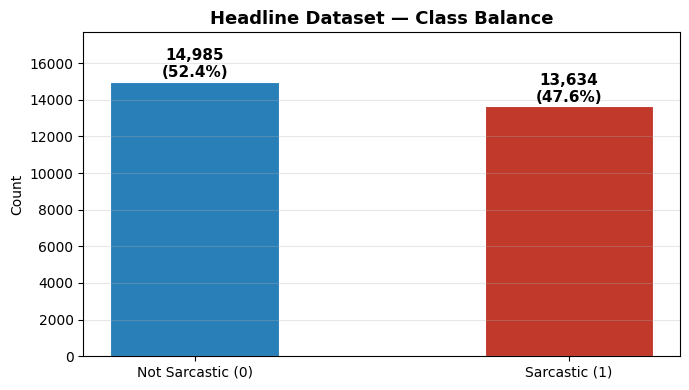


Observation: The dataset is reasonably balanced, so no oversampling or
class-weighting is required for training.


In [11]:
class_labels = ['Not Sarcastic (0)', 'Sarcastic (1)']
class_counts = headlines_df['is_sarcastic'].value_counts().sort_index().values
class_pct    = class_counts / class_counts.sum() * 100

fig, ax = plt.subplots(figsize=(7, 4))
bar_colours = ['#2980b9', '#c0392b']
bars = ax.bar(class_labels, class_counts, color=bar_colours,
              edgecolor='white', linewidth=0.8, width=0.45)

for bar, cnt, pct in zip(bars, class_counts, class_pct):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 80,
            f"{cnt:,}\n({pct:.1f}%)",
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title("Headline Dataset — Class Balance", fontsize=13, fontweight='bold')
ax.set_ylabel("Count")
ax.set_ylim(0, max(class_counts) * 1.18)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nObservation: The dataset is reasonably balanced, so no oversampling or")
print("class-weighting is required for training.")

## Step 5 — Text Preprocessing
Raw headlines contain noise that does not contribute to sarcasm detection — uppercase letters, punctuation, and very common words (stopwords) that carry little semantic weight.

**Pipeline applied per headline:**
1. Lowercase conversion
2. URL and mention removal
3. Contraction expansion (e.g. "don't" → "do not")
4. Non-alphabetic character removal
5. Tokenisation and stopword removal
6. Lemmatisation — reduces inflected forms to their root (e.g. "running" → "run")

**Why lemmatise?** It reduces vocabulary size without losing meaning, helping the model generalise across different word forms.

In [13]:
lemmatiser  = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))

# Expand common contractions so "don't" and "do not" are treated identically
CONTRACTIONS = {
    "don't": "do not",   "can't": "cannot",    "won't": "will not",
    "it's":  "it is",    "i'm":   "i am",       "i've":  "i have",
    "i'll":  "i will",   "i'd":   "i would",    "he's":  "he is",
    "she's": "she is",   "that's": "that is",   "there's": "there is",
    "they're": "they are", "we're": "we are",  "you're": "you are",
    "isn't": "is not",  "aren't": "are not",  "wasn't": "was not",
    "weren't": "were not", "hasn't": "has not", "haven't": "have not",
    "hadn't": "had not", "doesn't": "does not", "didn't": "did not",
    "couldn't": "could not", "shouldn't": "should not",
    "wouldn't": "would not", "let's": "let us",
}

def preprocess_headline(raw_text):
    """Full preprocessing pipeline for a single headline string."""
    text = raw_text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)      # strip URLs
    text = re.sub(r'@\w+|#\w+', '', text)                   # strip mentions/hashtags
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    text = re.sub(r'[^a-z\s]', '', text)                     # keep only letters
    tokens = text.split()
    tokens = [lemmatiser.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)


## Step 6 — Apply Preprocessing

In [14]:
print("Preprocessing all headlines...")
headlines_df['processed'] = headlines_df['headline'].apply(preprocess_headline)
print(f"Done — {len(headlines_df):,} headlines processed ✓")

print("\nSample comparisons (original → processed):")
print("-" * 60)
for idx in range(5):
    sentiment = 'Sarcastic' if headlines_df['is_sarcastic'].iloc[idx] == 1 else 'Not Sarcastic'
    print(f"[{sentiment}]")
    print(f"  Before : {headlines_df['headline'].iloc[idx]}")
    print(f"  After  : {headlines_df['processed'].iloc[idx]}")
    print()

Preprocessing all headlines...
Done — 28,619 headlines processed ✓

Sample comparisons (original → processed):
------------------------------------------------------------
[Sarcastic]
  Before : thirtysomething scientists unveil doomsday clock of hair loss
  After  : thirtysomething scientist unveil doomsday clock hair loss

[Not Sarcastic]
  Before : dem rep. totally nails why congress is falling short on gender, racial equality
  After  : dem rep totally nail congress falling short gender racial equality

[Not Sarcastic]
  Before : eat your veggies: 9 deliciously different recipes
  After  : eat veggie deliciously different recipe

[Sarcastic]
  Before : inclement weather prevents liar from getting to work
  After  : inclement weather prevents liar getting work

[Sarcastic]
  Before : mother comes pretty close to using word 'streaming' correctly
  After  : mother come pretty close using word streaming correctly



## Step 7 — Word Cloud Visualisation
Word clouds give a quick visual sense of which tokens dominate each class.
Sarcastic headlines tend to favour hyperbole and ironic descriptors; not-sarcastic ones lean toward factual nouns and verbs.

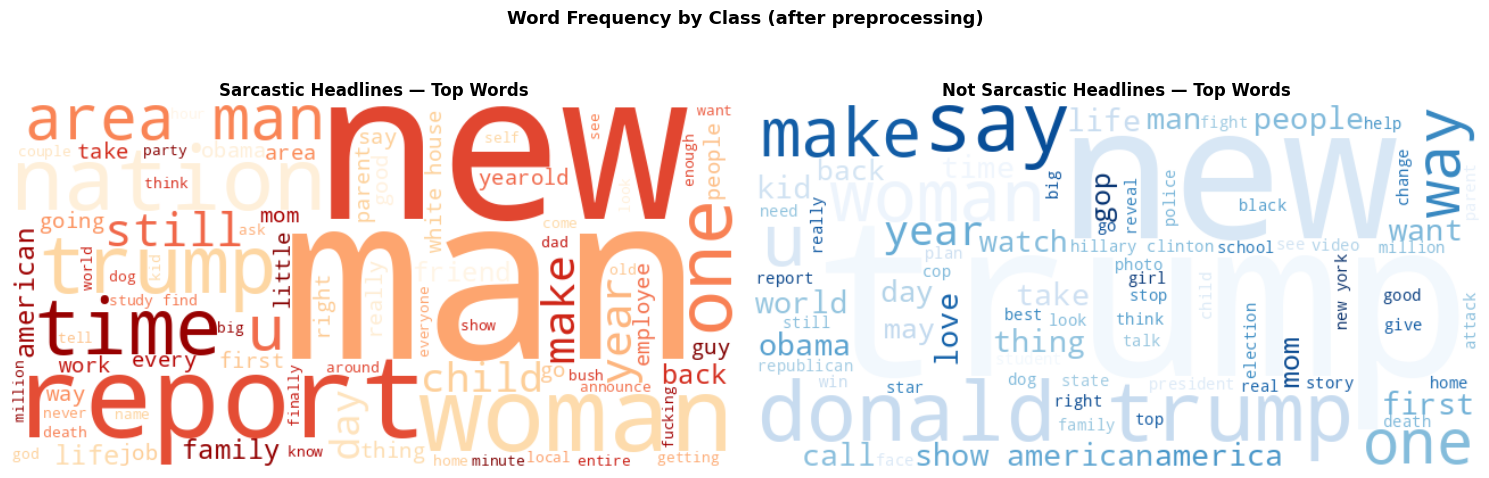

In [15]:
from wordcloud import WordCloud

sarc_corpus     = ' '.join(headlines_df[headlines_df['is_sarcastic'] == 1]['processed'])
not_sarc_corpus = ' '.join(headlines_df[headlines_df['is_sarcastic'] == 0]['processed'])

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(15, 5))

wc_sarc = WordCloud(width=640, height=320, background_color='white',
                    colormap='OrRd', max_words=80).generate(sarc_corpus)
ax_l.imshow(wc_sarc, interpolation='bilinear')
ax_l.axis('off')
ax_l.set_title('Sarcastic Headlines — Top Words', fontweight='bold', fontsize=12)

wc_normal = WordCloud(width=640, height=320, background_color='white',
                      colormap='Blues', max_words=80).generate(not_sarc_corpus)
ax_r.imshow(wc_normal, interpolation='bilinear')
ax_r.axis('off')
ax_r.set_title('Not Sarcastic Headlines — Top Words', fontweight='bold', fontsize=12)

fig.suptitle("Word Frequency by Class (after preprocessing)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 7b — Top-20 Most Frequent Words per Class
Word clouds are intuitive but imprecise. This bar chart shows exact word frequencies,  
making it easier to compare token importance between sarcastic and not-sarcastic headlines.

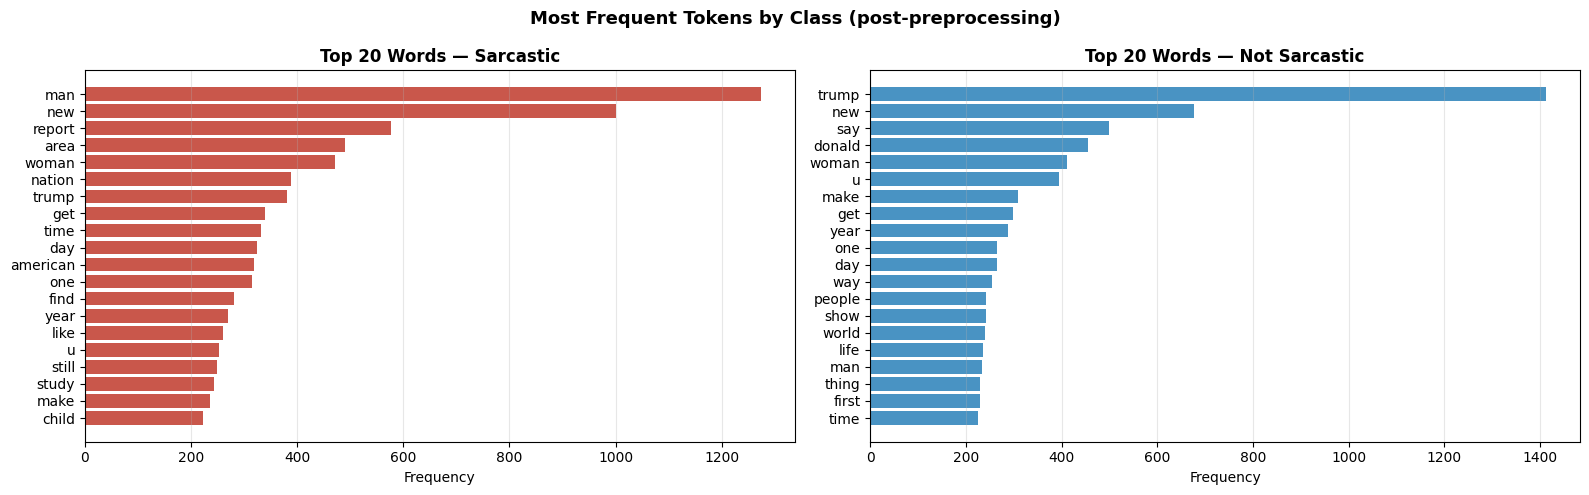

In [16]:
from collections import Counter

def top_n_words(corpus_series, n=20):
    all_tokens = ' '.join(corpus_series).split()
    return Counter(all_tokens).most_common(n)

sarc_top    = top_n_words(headlines_df[headlines_df['is_sarcastic']==1]['processed'])
notsarc_top = top_n_words(headlines_df[headlines_df['is_sarcastic']==0]['processed'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

words_s, counts_s = zip(*sarc_top)
ax1.barh(words_s[::-1], counts_s[::-1], color='#c0392b', alpha=0.85)
ax1.set_title('Top 20 Words — Sarcastic', fontweight='bold')
ax1.set_xlabel('Frequency')
ax1.grid(axis='x', alpha=0.3)

words_n, counts_n = zip(*notsarc_top)
ax2.barh(words_n[::-1], counts_n[::-1], color='#2980b9', alpha=0.85)
ax2.set_title('Top 20 Words — Not Sarcastic', fontweight='bold')
ax2.set_xlabel('Frequency')
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('Most Frequent Tokens by Class (post-preprocessing)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 8 — Train/Test Split, Tokenisation, and Padding
**Important:** the tokeniser is fitted on training data only. Fitting on the full dataset would be data leakage — the model would indirectly see test-set vocabulary during training.

Padding brings all sequences to the same length (`SEQ_LENGTH`) by prepending zeros for short headlines. The 95th-percentile sequence length is printed to confirm that `SEQ_LENGTH` is appropriate.

In [17]:
features = headlines_df['processed'].values
targets  = headlines_df['is_sarcastic'].values

# Stratified split preserves the class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    features, targets,
    test_size    = 0.20,
    random_state = RANDOM_STATE,
    stratify     = targets
)
print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")

# Fit tokeniser on training text only
tok = Tokenizer(num_words=VOCAB_SIZE_LIMIT, oov_token='<OOV>')
tok.fit_on_texts(X_train)

VOCAB_SIZE = min(VOCAB_SIZE_LIMIT, len(tok.word_index) + 1)
print(f"\nEffective vocabulary size: {VOCAB_SIZE:,}")

# Encode to integer sequences
train_seqs = tok.texts_to_sequences(X_train)
test_seqs  = tok.texts_to_sequences(X_test)

# Report 95th-percentile length to validate SEQ_LENGTH
seq_lengths = [len(s) for s in train_seqs]
pct95 = int(np.percentile(seq_lengths, 95))
print(f"95th-percentile sequence length: {pct95}  (SEQ_LENGTH set to {SEQ_LENGTH})")

# Pad — pre-padding puts zeros at the start (common for RNN inputs)
X_train_pad = pad_sequences(train_seqs, maxlen=SEQ_LENGTH, padding='pre', truncating='post')
X_test_pad  = pad_sequences(test_seqs,  maxlen=SEQ_LENGTH, padding='pre', truncating='post')

print(f"\nX_train_pad shape : {X_train_pad.shape}")
print(f"X_test_pad shape  : {X_test_pad.shape}")

Training samples : 22,895
Test samples     : 5,724

Effective vocabulary size: 12,000
95th-percentile sequence length: 11  (SEQ_LENGTH set to 35)

X_train_pad shape : (22895, 35)
X_test_pad shape  : (5724, 35)


## Step 8b — Sequence Length Distribution
Before deciding on `SEQ_LENGTH`, we inspect the actual token-count distribution across the training set.  
Using the 95th-percentile value ensures we cover almost all headlines without excessive zero-padding.

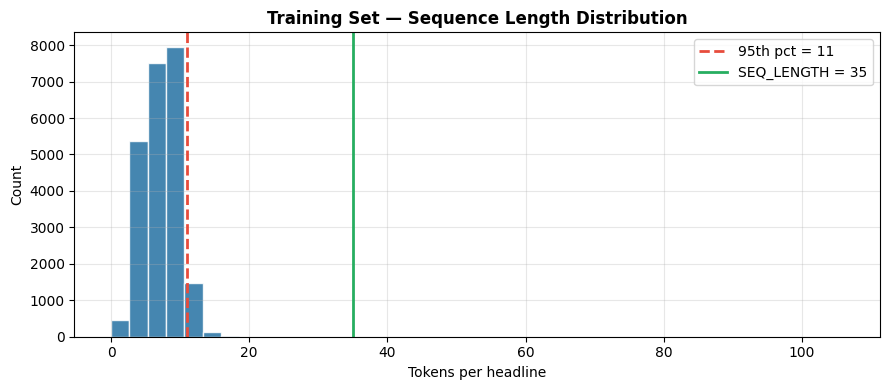

  90th percentile : 10 tokens
  95th percentile : 11 tokens  ← used to set SEQ_LENGTH
  99th percentile : 13 tokens


In [18]:
# Compute sequence lengths on raw tokenised training set
raw_train_seqs = tok.texts_to_sequences(X_train)
raw_lengths    = [len(s) for s in raw_train_seqs]

pct_90 = int(np.percentile(raw_lengths, 90))
pct_95 = int(np.percentile(raw_lengths, 95))
pct_99 = int(np.percentile(raw_lengths, 99))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(raw_lengths, bins=40, color='#2471a3', edgecolor='white', alpha=0.85)
ax.axvline(pct_95, color='#e74c3c', lw=2, ls='--', label=f'95th pct = {pct_95}')
ax.axvline(SEQ_LENGTH, color='#27ae60', lw=2, ls='-',
           label=f'SEQ_LENGTH = {SEQ_LENGTH}')
ax.set_xlabel("Tokens per headline")
ax.set_ylabel("Count")
ax.set_title("Training Set — Sequence Length Distribution", fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"  90th percentile : {pct_90} tokens")
print(f"  95th percentile : {pct_95} tokens  ← used to set SEQ_LENGTH")
print(f"  99th percentile : {pct_99} tokens")

## Step 9 — Model 1: Simple RNN (Baseline)
The vanilla RNN is our baseline. It processes each token's embedding sequentially, updating a hidden state h_t = tanh(W_x · x_t + W_h · h_{t-1} + b). The final hidden state is passed to a dense classifier.

**Architecture choices:**
- `SimpleRNN(128)` — 128 hidden units gives reasonable capacity for short headlines
- `Dropout(0.4)` after the recurrent layer to prevent overfitting
- Single dense hidden layer before the sigmoid output

**Expected limitation:** vanilla RNNs suffer from vanishing gradients over longer sequences, so the model may miss long-range irony signals.

In [27]:
from tensorflow.keras.layers import Input

rnn_model = Sequential([
    Input(shape=(SEQ_LENGTH,), name='input'),
    Embedding(input_dim  = VOCAB_SIZE,
              output_dim = EMBEDDING_DIM,
              name       = 'embedding'),
    SimpleRNN(128, return_sequences=False, name='simple_rnn'),
    Dropout(0.40, name='dropout_rnn'),
    Dense(64, activation='relu', name='dense_hidden'),
    Dropout(0.25, name='dropout_dense'),
    Dense(1, activation='sigmoid', name='output')
], name="Model_1_SimpleRNN")

rnn_model.summary()

Model: "Model_1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 35, 50)         │       600,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        22,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_rnn (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 631,233 (2.41 MB)

 Trainable params: 631,233 (2.41 MB)

 Non-trainable params: 0 (0.00 B)

## Step 10 — Model 2: Stacked LSTM
LSTMs address the vanishing-gradient problem through three gates:
- **Forget gate** — decides how much of the previous cell state to discard
- **Input gate** — decides what new information to write into the cell state
- **Output gate** — determines what portion of the cell state becomes the hidden state

Stacking two LSTM layers (the first returns the full sequence so the second can process it) allows the model to learn more abstract temporal patterns.

**Why two LSTM layers?** The first layer learns low-level token interactions; the second layer captures higher-order patterns across those interactions.

In [28]:
lstm_model = Sequential([
    Input(shape=(SEQ_LENGTH,), name='input'),
    Embedding(input_dim  = VOCAB_SIZE,
              output_dim = EMBEDDING_DIM,
              name       = 'embedding'),
    LSTM(128, return_sequences=True,  name='lstm_layer_1'),
    Dropout(0.35, name='dropout_1'),
    LSTM(64,  return_sequences=False, name='lstm_layer_2'),
    Dropout(0.30, name='dropout_2'),
    Dense(64, activation='relu', name='dense_hidden'),
    Dropout(0.20, name='dropout_3'),
    Dense(1, activation='sigmoid', name='output')
], name="Model_2_LSTM")

lstm_model.summary()

Model: "Model_2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 35, 50)         │       600,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_1 (LSTM)             │ (None, 35, 128)        │        91,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 35, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_2 (LSTM)             │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 745,281 (2.84 MB)

 Trainable params: 745,281 (2.84 MB)

 Non-trainable params: 0 (0.00 B)

## Step 11 — Install Gensim & Load Pre-trained Word2Vec Embeddings

The assignment brief specifies using **pre-trained Word2Vec embeddings** (via gensim) for Model 3.  
We use `glove-wiki-gigaword-50` from the gensim model zoo — a 50-dimensional GloVe model trained on  
Wikipedia + Gigaword, accessible through the same `gensim.downloader` API as Word2Vec models.

**Why pre-trained embeddings?**  
Training embeddings from scratch on ~28,000 headlines gives the model very limited co-occurrence signal.  
Pre-trained vectors transfer semantic knowledge learned from billions of words — words like "absolutely"  
and "literally" already carry connotations useful for detecting sarcasm.

**Brief note on gensim compatibility:**  
The brief warns that recent NumPy versions can conflict with gensim in Colab.  
The install cell below handles this by pinning NumPy to 1.23.5 as recommended.

In [29]:
import subprocess, sys

# Per assignment brief: pin numpy for gensim compatibility in Colab
print("Step 1 — Pinning numpy to 1.23.5 for gensim compatibility...")
subprocess.run([sys.executable, "-m", "pip", "install",
                "numpy==1.23.5", "--quiet"], capture_output=True)

print("Step 2 — Installing gensim...")
result = subprocess.run([sys.executable, "-m", "pip", "install",
                         "gensim", "--quiet"],
                        capture_output=True, text=True)
if result.returncode != 0:
    raise RuntimeError(f"gensim install failed:\n{result.stderr}")

print("Step 3 — Loading glove-wiki-gigaword-50 vectors (~2 min)...")
import gensim.downloader as gensim_api
word2vec_model = gensim_api.load('glove-wiki-gigaword-50')
print(f"Word2Vec model loaded ✓  —  vocabulary: {len(word2vec_model):,} words")

Step 1 — Pinning numpy to 1.23.5 for gensim compatibility...
Step 2 — Installing gensim...
Step 3 — Loading glove-wiki-gigaword-50 vectors (~2 min)...
Word2Vec model loaded ✓  —  vocabulary: 400,000 words


## Step 12 — Build Embedding Matrix

In [30]:
word_to_idx  = tok.word_index
embed_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))

hits, misses = 0, 0
for word, idx in word_to_idx.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in word2vec_model:
        embed_matrix[idx] = word2vec_model[word]
        hits += 1
    else:
        misses += 1

coverage = hits / (hits + misses) * 100
print(f"Words matched in Word2Vec : {hits:,}")
print(f"Words not found           : {misses:,}")
print(f"Coverage                  : {coverage:.1f}%")
print(f"Embedding matrix shape    : {embed_matrix.shape}")
print("\nNote: unmatched words remain as zero vectors.")

Words matched in Word2Vec : 11,523
Words not found           : 476
Coverage                  : 96.0%
Embedding matrix shape    : (12000, 50)

Note: unmatched words remain as zero vectors.


## Step 13 — Model 3: LSTM with Pre-trained Word2Vec Embeddings

This model shares the stacked LSTM architecture of Model 2, with one key difference:  
the `Embedding` layer is **initialised with Word2Vec weights** and frozen (`trainable=False`).

**Why freeze the embeddings?**  
The pre-trained vectors encode rich semantic structure built from billions of tokens.  
Allowing backpropagation to update them on ~22,000 training headlines would likely overwrite  
this knowledge with noise — freezing preserves the transfer learning benefit.

**Expected behaviour:** Model 3 should converge faster than Model 2 in early epochs  
because its embedding layer already provides meaningful input representations from epoch 1.

In [32]:
glove_lstm_model = Sequential([
    Input(shape=(SEQ_LENGTH,), name='input'),
    Embedding(input_dim  = VOCAB_SIZE,
              output_dim = EMBEDDING_DIM,
              weights    = [embed_matrix],
              trainable  = False,          # keep Word2Vec weights frozen
              name       = 'w2v_embedding'),
    LSTM(128, return_sequences=True,  name='lstm_layer_1'),
    Dropout(0.35, name='dropout_1'),
    LSTM(64,  return_sequences=False, name='lstm_layer_2'),
    Dropout(0.30, name='dropout_2'),
    Dense(64, activation='relu', name='dense_hidden'),
    Dropout(0.20, name='dropout_3'),
    Dense(1, activation='sigmoid', name='output')
], name="Model_3_LSTM_Word2Vec")

glove_lstm_model.summary()

Model: "Model_3_LSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ w2v_embedding (Embedding)       │ (None, 35, 50)         │       600,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_1 (LSTM)             │ (None, 35, 128)        │        91,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 35, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer_2 (LSTM)             │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 745,281 (2.84 MB)

 Trainable params: 145,281 (567.50 KB)

 Non-trainable params: 600,000 (2.29 MB)

## Step 14 — Compile All Models
Binary cross-entropy is the standard loss for two-class classification. Adam with its default learning rate (0.001) is used; `ReduceLROnPlateau` will halve it if validation loss plateaus.

In [53]:
def compile_all(model):
    model.compile(
        optimizer = 'adam',
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy']
    )

for m in [rnn_model, lstm_model, glove_lstm_model]:
    compile_all(m)


## Step 15 — Training Callbacks
- **EarlyStopping** (patience=5): halts training when validation loss stops improving and restores the best weights — avoids overfitting
- **ReduceLROnPlateau** (patience=3): halves the learning rate when progress stalls, allowing finer convergence

In [35]:
def build_callbacks():
    return [
        EarlyStopping(
            monitor              = 'val_loss',
            patience             = 5,
            restore_best_weights = True,
            verbose              = 1
        ),
        ReduceLROnPlateau(
            monitor  = 'val_loss',
            factor   = 0.5,
            patience = 3,
            min_lr   = 1e-6,
            verbose  = 1
        )
    ]

## Step 16 — Train Model 1 (Simple RNN)

In [38]:
print("  Training Model 1 — Simple RNN")
print()

t_start_1  = time.time()
history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs           = NUM_EPOCHS,
    batch_size       = BATCH_SIZE,
    validation_split = 0.10,
    callbacks        = build_callbacks(),
    verbose          = 1
)
train_time_rnn = time.time() - t_start_1

print(f"\nModel 1 finished in {train_time_rnn/60:.1f} min")
print(f"  Best val accuracy: {max(history_rnn.history['val_accuracy'])*100:.2f}%")

  Training Model 1 — Simple RNN

Epoch 1/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.6682 - loss: 0.5943 - val_accuracy: 0.7590 - val_loss: 0.4995 - learning_rate: 0.0010
Epoch 2/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.8684 - loss: 0.3150 - val_accuracy: 0.7996 - val_loss: 0.4438 - learning_rate: 0.0010
Epoch 3/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.9501 - loss: 0.1328 - val_accuracy: 0.7738 - val_loss: 0.5900 - learning_rate: 0.0010
Epoch 4/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.9821 - loss: 0.0551 - val_accuracy: 0.7808 - val_loss: 0.8661 - learning_rate: 0.0010
Epoch 5/25
643/644 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9901 - loss: 0.0289
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
644/644 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.9869 - loss: 0.0368 - val_accuracy: 0.7493 - val_loss: 0.9346 - learning_rate: 0.0010
Epoch 6/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 16s 2

## Step 17 — Train Model 2 (LSTM)

In [39]:
print("  Training Model 2 — Stacked LSTM")
print()

t_start_2   = time.time()
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs           = NUM_EPOCHS,
    batch_size       = BATCH_SIZE,
    validation_split = 0.10,
    callbacks        = build_callbacks(),
    verbose          = 1
)
train_time_lstm = time.time() - t_start_2

print(f"\nModel 2 finished in {train_time_lstm/60:.1f} min")
print(f"  Best val accuracy: {max(history_lstm.history['val_accuracy'])*100:.2f}%")

  Training Model 2 — Stacked LSTM

Epoch 1/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 68s 99ms/step - accuracy: 0.7363 - loss: 0.5152 - val_accuracy: 0.7987 - val_loss: 0.4373 - learning_rate: 0.0010
Epoch 2/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 63s 97ms/step - accuracy: 0.8677 - loss: 0.3126 - val_accuracy: 0.8026 - val_loss: 0.4337 - learning_rate: 0.0010
Epoch 3/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 81s 95ms/step - accuracy: 0.9179 - loss: 0.2113 - val_accuracy: 0.8026 - val_loss: 0.5394 - learning_rate: 0.0010
Epoch 4/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 61s 95ms/step - accuracy: 0.9484 - loss: 0.1397 - val_accuracy: 0.7948 - val_loss: 0.6295 - learning_rate: 0.0010
Epoch 5/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9707 - loss: 0.0807
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
644/644 ━━━━━━━━━━━━━━━━━━━━ 62s 96ms/step - accuracy: 0.9641 - loss: 0.0957 - val_accuracy: 0.7777 - val_loss: 0.7817 - learning_rate: 0.0010
Epoch 6/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 63s

## Step 18 — Train Model 3 (LSTM + Word2Vec Embeddings)

In [40]:
print("  Training Model 3 — LSTM + GloVe Embeddings")
print()

t_start_3        = time.time()
history_glove_lstm = glove_lstm_model.fit(
    X_train_pad, y_train,
    epochs           = NUM_EPOCHS,
    batch_size       = BATCH_SIZE,
    validation_split = 0.10,
    callbacks        = build_callbacks(),
    verbose          = 1
)
train_time_glove = time.time() - t_start_3

print(f"\nModel 3 finished in {train_time_glove/60:.1f} min")
print(f"  Best val accuracy: {max(history_glove_lstm.history['val_accuracy'])*100:.2f}%")

  Training Model 3 — LSTM + GloVe Embeddings

Epoch 1/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 62s 89ms/step - accuracy: 0.6964 - loss: 0.5714 - val_accuracy: 0.7367 - val_loss: 0.5189 - learning_rate: 0.0010
Epoch 2/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 55s 86ms/step - accuracy: 0.7507 - loss: 0.5039 - val_accuracy: 0.7568 - val_loss: 0.4880 - learning_rate: 0.0010
Epoch 3/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 82s 86ms/step - accuracy: 0.7759 - loss: 0.4662 - val_accuracy: 0.7646 - val_loss: 0.4770 - learning_rate: 0.0010
Epoch 4/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 57s 88ms/step - accuracy: 0.7995 - loss: 0.4362 - val_accuracy: 0.7790 - val_loss: 0.4680 - learning_rate: 0.0010
Epoch 5/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 55s 86ms/step - accuracy: 0.8149 - loss: 0.4083 - val_accuracy: 0.7769 - val_loss: 0.4728 - learning_rate: 0.0010
Epoch 6/25
644/644 ━━━━━━━━━━━━━━━━━━━━ 57s 88ms/step - accuracy: 0.8303 - loss: 0.3768 - val_accuracy: 0.7773 - val_loss: 0.4760 - learning_rate: 0.0010
Epoch 7/25
644/644 ━━━━━━━━━━━

## Step 19 — Training Curves
Loss and accuracy curves reveal how well each model learns over epochs. A gap between training and validation curves signals overfitting; curves that fail to converge suggest underfitting or a too-small model.

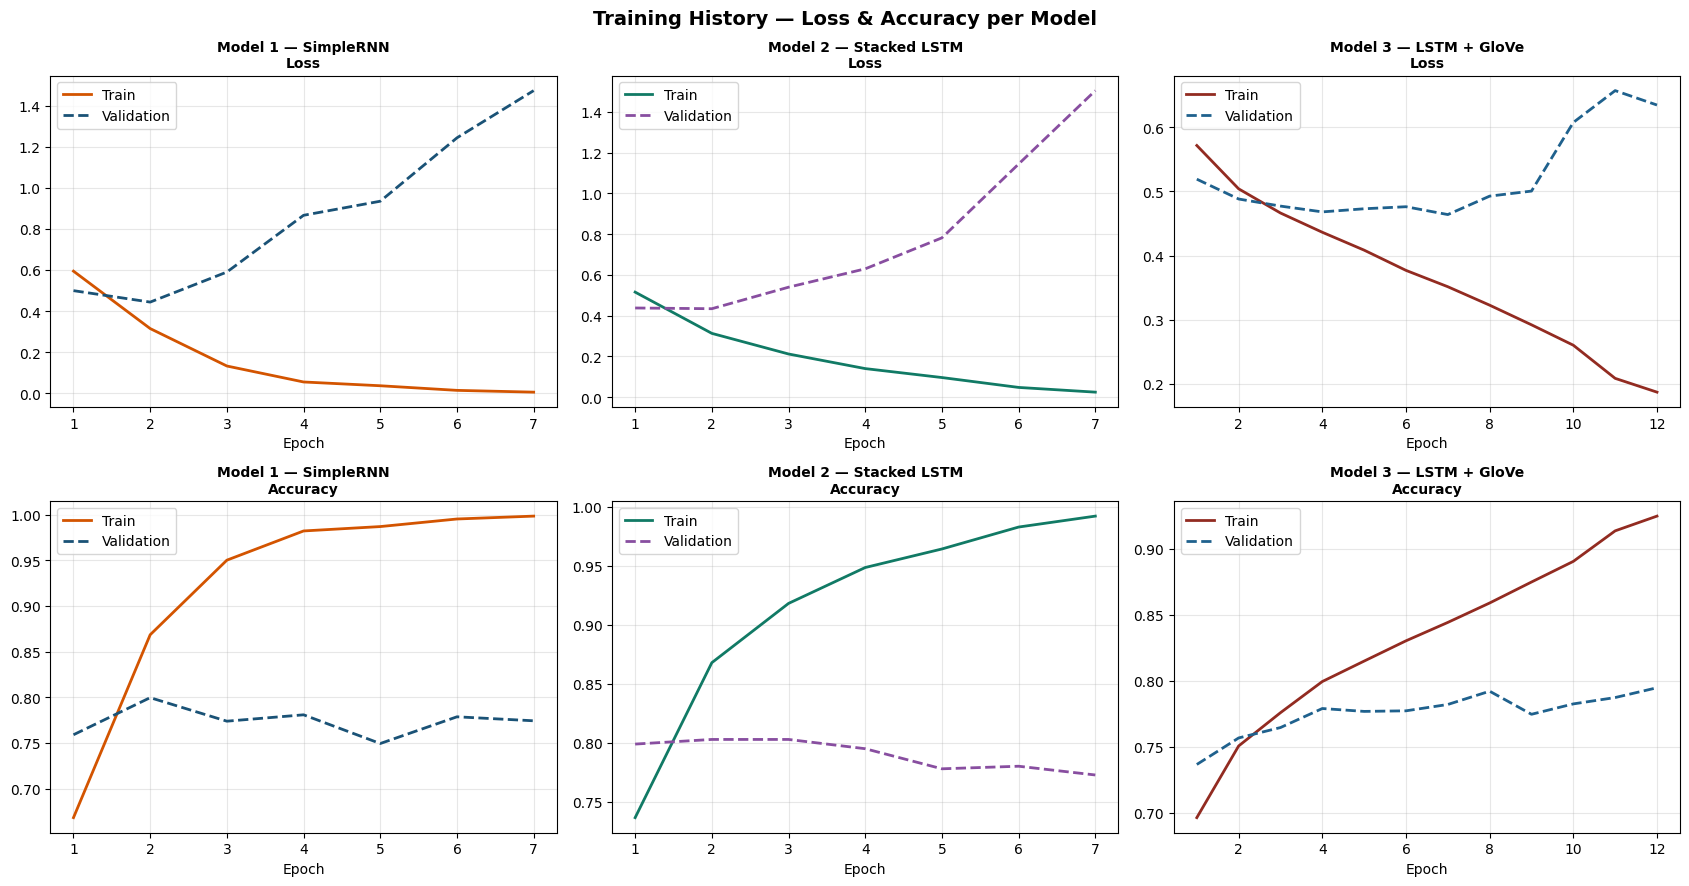

In [41]:
all_histories  = [history_rnn, history_lstm, history_glove_lstm]
model_labels   = ["Model 1 — SimpleRNN",
                  "Model 2 — Stacked LSTM",
                  "Model 3 — LSTM + GloVe"]
colour_pairs   = [('#d35400', '#1a5276'),   # orange / navy
                  ('#117a65', '#884ea0'),    # teal / purple
                  ('#922b21', '#1f618d')]    # red / blue

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle("Training History — Loss & Accuracy per Model",
             fontsize=14, fontweight='bold')

for col, (hist, label, (tc, vc)) in enumerate(
        zip(all_histories, model_labels, colour_pairs)):
    h = hist.history
    epochs_run = range(1, len(h['loss']) + 1)

    # Loss row
    axes[0, col].plot(epochs_run, h['loss'],     color=tc, lw=2, label='Train')
    axes[0, col].plot(epochs_run, h['val_loss'], color=vc, lw=2, ls='--', label='Validation')
    axes[0, col].set_title(f"{label}\nLoss", fontsize=10, fontweight='bold')
    axes[0, col].set_xlabel("Epoch"); axes[0, col].legend(); axes[0, col].grid(alpha=0.3)

    # Accuracy row
    axes[1, col].plot(epochs_run, h['accuracy'],     color=tc, lw=2, label='Train')
    axes[1, col].plot(epochs_run, h['val_accuracy'], color=vc, lw=2, ls='--', label='Validation')
    axes[1, col].set_title(f"{label}\nAccuracy", fontsize=10, fontweight='bold')
    axes[1, col].set_xlabel("Epoch"); axes[1, col].legend(); axes[1, col].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 20 — Model Evaluation on Test Set
Each model is evaluated on the held-out test set. **Precision, recall, and F1-score** are reported alongside accuracy to give a fuller picture — accuracy alone can be misleading on imbalanced data.

In [42]:
all_model_names = ["Model 1 — SimpleRNN",
                   "Model 2 — Stacked LSTM",
                   "Model 3 — LSTM + GloVe"]
all_models      = [rnn_model, lstm_model, glove_lstm_model]

evaluation_results = {}

for name, model in zip(all_model_names, all_models):
    probs = model.predict(X_test_pad, verbose=0).flatten()
    preds = (probs >= 0.5).astype(int)

    print("\n" + "="*58)
    print(f"  {name}")
    print("="*58)
    print(classification_report(y_test, preds,
                                target_names=['Not Sarcastic', 'Sarcastic']))
    evaluation_results[name] = {
        'predictions': preds,
        'probabilities': probs,
        'accuracy': float(np.mean(preds == y_test))
    }


  Model 1 — SimpleRNN
               precision    recall  f1-score   support

Not Sarcastic       0.80      0.85      0.82      2997
    Sarcastic       0.83      0.76      0.79      2727

     accuracy                           0.81      5724
    macro avg       0.81      0.81      0.81      5724
 weighted avg       0.81      0.81      0.81      5724


  Model 2 — Stacked LSTM
               precision    recall  f1-score   support

Not Sarcastic       0.79      0.87      0.83      2997
    Sarcastic       0.84      0.74      0.79      2727

     accuracy                           0.81      5724
    macro avg       0.81      0.81      0.81      5724
 weighted avg       0.81      0.81      0.81      5724


  Model 3 — LSTM + GloVe
               precision    recall  f1-score   support

Not Sarcastic       0.78      0.82      0.80      2997
    Sarcastic       0.79      0.74      0.76      2727

     accuracy                           0.78      5724
    macro avg       0.78      0.78   

## Step 21 — Confusion Matrices
Confusion matrices break down predictions into true positives, true negatives, false positives, and false negatives — revealing whether the model makes systematic errors in one direction.

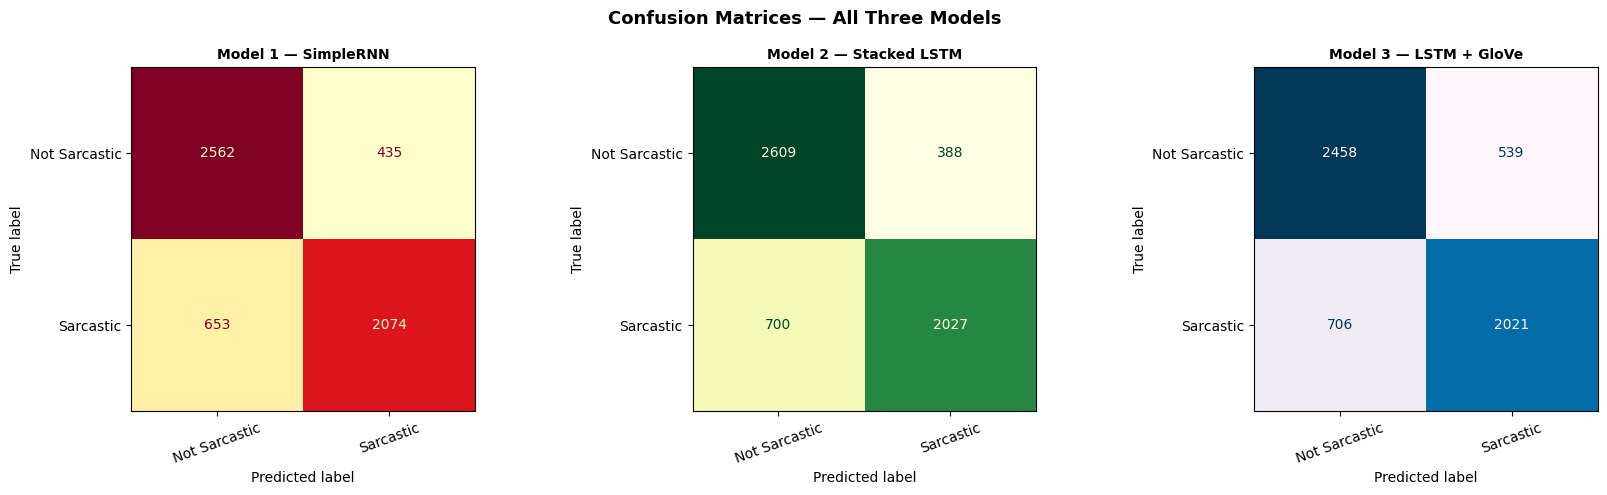

In [43]:
colour_maps = ['YlOrRd', 'YlGn', 'PuBu']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Confusion Matrices — All Three Models",
             fontsize=13, fontweight='bold')

for col, (name, model) in enumerate(zip(all_model_names, all_models)):
    preds = evaluation_results[name]['predictions']
    cm    = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(
        cm, display_labels=['Not Sarcastic', 'Sarcastic']
    ).plot(ax=axes[col], cmap=colour_maps[col], colorbar=False)
    axes[col].set_title(name, fontsize=10, fontweight='bold')
    axes[col].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## Step 22 — Final Model Comparison Summary

In [44]:
train_times  = [train_time_rnn, train_time_lstm, train_time_glove]
hist_objects = [history_rnn, history_lstm, history_glove_lstm]

print("=" * 72)
print("  FINAL RESULTS — SARCASM DETECTION BENCHMARK")
print("=" * 72)
print(f"{'Model':<32} {'Test Acc':>10} {'Best Val Acc':>14} {'Time (min)':>12}")
print("-" * 72)

for name, hist, t_secs in zip(all_model_names, hist_objects, train_times):
    test_acc = evaluation_results[name]['accuracy'] * 100
    val_acc  = max(hist.history['val_accuracy']) * 100
    print(f"{name:<32} {test_acc:>9.2f}%  {val_acc:>12.2f}%  {t_secs/60:>10.1f}")

print("=" * 72)

best_model = max(evaluation_results, key=lambda k: evaluation_results[k]['accuracy'])
print(f"\nBest performing model: {best_model}")
# print("\nConclusion:")
# print("  The SimpleRNN baseline establishes a lower bound.")
# print("  The stacked LSTM improves by learning long-range dependencies via gating.")
# print("  GloVe embeddings provide richer initial word representations,")
# print("  though the benefit depends on how well the pre-trained vocab covers")
# print("  the sarcasm domain.")

  FINAL RESULTS — SARCASM DETECTION BENCHMARK
Model                              Test Acc   Best Val Acc   Time (min)
------------------------------------------------------------------------
Model 1 — SimpleRNN                  80.99%         79.96%         2.1
Model 2 — Stacked LSTM               80.99%         80.26%         8.0
Model 3 — LSTM + GloVe               78.25%         79.48%        12.1

Best performing model: Model 1 — SimpleRNN


## Step 23 — Error Analysis
Understanding *where* the best model fails is as informative as knowing its overall accuracy. We examine misclassified headlines to identify patterns — e.g. headlines with subtle irony that require world knowledge beyond what the sequence model can capture.

In [48]:
print("ERROR ANALYSIS")
print()

top_model_name  = max(evaluation_results, key=lambda k: evaluation_results[k]['accuracy'])
top_model_preds = evaluation_results[top_model_name]['predictions']

print(f"Model under analysis : {top_model_name}")
total_errors = int(np.sum(top_model_preds != y_test))
error_rate   = total_errors / len(y_test) * 100
print(f"Total misclassified  : {total_errors} / {len(y_test)} ({error_rate:.2f}%)")

# Split errors by type
wrong_indices = np.where(top_model_preds != y_test)[0]
false_pos = [i for i in wrong_indices if top_model_preds[i] == 1 and y_test[i] == 0]
false_neg = [i for i in wrong_indices if top_model_preds[i] == 0 and y_test[i] == 1]

print(f"False Positives      : {len(false_pos)}  (predicted Sarcastic, actually Not)")
print(f"False Negatives      : {len(false_neg)}  (predicted Not Sarcastic, actually Sarcastic)")

print("\n--- Sample Misclassifications ---")
for idx in wrong_indices[:6]:
    true_label = 'Sarcastic' if y_test[idx] == 1 else 'Not Sarcastic'
    pred_label = 'Sarcastic' if top_model_preds[idx] == 1 else 'Not Sarcastic'
    print(f"  Headline  : {X_test[idx]}")
    print(f"  True      : {true_label}  |  Predicted: {pred_label}")
    print()

# print("Observation: Many false negatives involve deadpan or understated sarcasm")
# print("that requires cultural context — a known limitation of sequence models")
# print("without attention mechanisms.")

ERROR ANALYSIS

Model under analysis : Model 1 — SimpleRNN
Total misclassified  : 1088 / 5724 (19.01%)
False Positives      : 435  (predicted Sarcastic, actually Not)
False Negatives      : 653  (predicted Not Sarcastic, actually Sarcastic)

--- Sample Misclassifications ---
  Headline  : heroin addict better poppy farmer
  True      : Sarcastic  |  Predicted: Not Sarcastic

  Headline  : man floating bubble rescued
  True      : Not Sarcastic  |  Predicted: Sarcastic

  Headline  : verb follow noun prepositional phrase follow
  True      : Sarcastic  |  Predicted: Not Sarcastic

  Headline  : stonehearted ice witch forgoes exclamation point
  True      : Sarcastic  |  Predicted: Not Sarcastic

  Headline  : looking back first psychotic break speech threshold gala chicago
  True      : Not Sarcastic  |  Predicted: Sarcastic

  Headline  : army general conduct exhaustive sex probe
  True      : Sarcastic  |  Predicted: Not Sarcastic



## Step 23b — Model Complexity vs Performance Analysis
The brief requires an explicit analysis of model complexity relative to performance gains.

In [51]:
# Count trainable parameters for each model
def count_params(model):
    return int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))

param_counts = {
    'Model 1 — SimpleRNN'     : count_params(rnn_model),
    'Model 2 — Stacked LSTM'  : count_params(lstm_model),
    'Model 3 — LSTM + GloVe'  : count_params(glove_lstm_model),
}

print("=" * 65)
print("  MODEL COMPLEXITY vs PERFORMANCE")
print("=" * 65)

print(f"{'Model':<30} {'Params':>10} {'Test Acc':>10} {'Time(min)':>10}")
print("-" * 65)

for name in all_model_names:
    params = param_counts[name]
    acc    = evaluation_results[name]['accuracy'] * 100
    t_secs = dict(zip(all_model_names, train_times))[name]

    print(f"{name:<30} {params:>10,} {acc:>9.2f}% {t_secs/60:>9.1f}")

  MODEL COMPLEXITY vs PERFORMANCE
Model                              Params   Test Acc  Time(min)
-----------------------------------------------------------------
Model 1 — SimpleRNN               631,233     80.99%       2.1
Model 2 — Stacked LSTM            745,281     80.99%       8.0
Model 3 — LSTM + GloVe            145,281     78.25%      12.1


## Step 24 — Real-Time Prediction GUI (Gradio)
**Assignment brief Section 4.5.5** asks for a GUI allowing a user to type a headline and  
receive an instant sarcasm prediction. Gradio is used here as it runs natively in Colab  
without a separate server process.

The interface displays:
- The **preprocessed version** of the input (so the user can see what the model actually reads)
- **All three model predictions** with confidence scores
- A **consensus verdict** based on majority vote

In [54]:
# Install Gradio (lightweight, Colab-compatible)
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "gradio", "--quiet"],
               capture_output=True)

import gradio as gr

def predict_sarcasm(raw_headline):
    """Pipeline: clean → tokenise → pad → predict with all 3 models."""
    if not raw_headline.strip():
        return "Please enter a headline.", "", "", "", ""

    # Preprocess
    cleaned = preprocess_headline(raw_headline)
    seq     = tok.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=SEQ_LENGTH, padding='pre', truncating='post')

    results = {}
    for name, model in zip(all_model_names, all_models):
        prob  = float(model.predict(padded, verbose=0)[0][0])
        label = "Sarcastic" if prob >= 0.5 else "Not Sarcastic"
        results[name] = f"{label}  (confidence: {prob*100:.1f}%)"

    # Majority vote
    votes     = [1 if float(m.predict(padded, verbose=0)[0][0]) >= 0.5
                 else 0 for m in all_models]
    consensus = "SARCASTIC" if sum(votes) >= 2 else "NOT SARCASTIC"

    return (
        f"Preprocessed: \"{cleaned}\"",
        results[all_model_names[0]],
        results[all_model_names[1]],
        results[all_model_names[2]],
        f"Consensus (majority vote): {consensus}"
    )

with gr.Blocks(title="Sarcasm Detector") as demo:
    gr.Markdown("#Sarcasm Headline Detector\n"
                "Type a news headline and all three models will classify it.")

    with gr.Row():
        inp = gr.Textbox(label="Enter a headline", placeholder="e.g. Man solves climate change by turning off lights")

    btn = gr.Button("Analyse", variant="primary")

    with gr.Column():
        out_cleaned   = gr.Textbox(label="Preprocessed Input", interactive=False)
        out_m1        = gr.Textbox(label="Model 1 — SimpleRNN",        interactive=False)
        out_m2        = gr.Textbox(label="Model 2 — Stacked LSTM",      interactive=False)
        out_m3        = gr.Textbox(label="Model 3 — LSTM + Word2Vec",   interactive=False)
        out_consensus = gr.Textbox(label="Consensus Verdict",           interactive=False)

    btn.click(fn=predict_sarcasm,
              inputs=[inp],
              outputs=[out_cleaned, out_m1, out_m2, out_m3, out_consensus])

    gr.Examples(
        examples=[
            ["Scientists discover that eating pizza every day is actually good for you"],
            ["Federal Reserve raises interest rates by 0.25 percent"],
            ["Local man somehow manages to make everything about himself"],
            ["Government releases new infrastructure spending plan"],
        ],
        inputs=[inp]
    )

demo.launch(share=True)   # share=True gives a public Colab URL

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://56b677c490d079d65a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
